# Lab: Deep Learning MLP with PyTorch

* Author: geoffroy.peeters@telecom-paris.fr
* Date: 2026-02-18

The goal of the Lab is to use (train and test) an MLP for a multi-class classification task on real data.

You will
- download the data from the internet.
- process the data using Pandas:
    - load the .xls file, split into X and y, split into train and eval-set.
- create a pytorch Dataset to allow getting them on the fly.
- write an MLP model using the `nn.Module` class formalism.
- write a loop over epochs in wich you train the model over mini-batch of the training-set and evaluate over the eval-set.
    - display at each epoch the losses and accuracies over training and test data.
- plot the losses and accuracies evoluation over epochs.

You will use the 'Dry Bean Dataset' descibed here https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset and downloadable here https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip.

## Your tasks
- 1) Fill-in the missing part
- 2) Correct the error mades in the text and in the provided code


# Import packages

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import urllib.request

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Data acquisition

Get the Dry Bean Dataset

Documentation: https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset

URL: https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip

In [ ]:
!rm DryBeanDataset.zip
!rm -rf ./DryBeanDataset

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00602/DryBeanDataset.zip"
urllib.request.urlretrieve(url, "DryBeanDataset.zip")

!unzip DryBeanDataset.zip

Archive:  DryBeanDataset.zip
   creating: DryBeanDataset/
  inflating: DryBeanDataset/Dry_Bean_Dataset.arff  
  inflating: DryBeanDataset/Dry_Bean_Dataset.txt  
  inflating: DryBeanDataset/Dry_Bean_Dataset.xlsx  


# Data preprocessing (using pandas and sklearn)

Process the data
* load the .xls file data using `pandas` (read_excel)
* split into X (all columns except `Class`) and y (column `Class`) using `pandas`
* convert y to integer using `sklearn` (LabelEncoder)
* split into train and valid datasets using `sklearn` (train_test_split), we use a 80\% train, 20\% validation split
* standardize the X of train and valid using `sklearn` (StandardScaler)



In [ ]:
def load_and_preprocess(data_file):
    # --- 1
    df = pd.read_excel(data_file)
    y = df['Class'].to_numpy()
    X = df.drop('Class', axis=1).to_numpy()
    X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size=0.2)

    label_encoder = LabelEncoder()
    label_encoder.fit(y_train)
    y_train=label_encoder.transform(y_train)
    y_valid=label_encoder.transform(y_valid)

    scaler = StandardScaler()
    scaler.fit(X_train, y_train)
    X_train = scaler.transform(X_train)
    X_valid = scaler.transform(X_valid)
    return X_train, X_valid, y_train, y_valid, len(np.unique(y))

data_file = 'DryBeanDataset/Dry_Bean_Dataset.xlsx'
X_train, X_valid, y_train, y_valid, num_classes = load_and_preprocess(data_file)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(set(y_train))

print(X_valid.shape)
print(y_valid.shape)
print(set(y_valid))

(10888, 16)
(10888,)
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}
(2723, 16)
(2723,)
{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)}


# Write the pytorch Dataset and Dataloader

create a pytorch Dataset to allow getting X and y on the fly
* we need to convert the data from numpy to torch-tensors

In [ ]:
# --- 2
class BeanDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.asarray(X)
        self.y = torch.asarray(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = BeanDataset(X_train, y_train)
valid_dataset = BeanDataset(X_valid, y_valid)

# DataLoaders handle batching, shuffling, and multi-process loading.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False) # Error here : it's valid_dataset

# Write the MLP model using `nn.Module`

The MLP model as the following architecture: `input_dim -> 128 -> 64 -> 64 -> output_dim`
* `output_dim`corresponds to the number of classes
* we put a `ReLU` between each layer
* we DON'T use a `softmax` activation at the end (since we deal with a multi-class problem)

In [ ]:
# --- 3
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.nn=nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim),
        )

    def forward(self, x):
        x_tensor = torch.asarray(x, dtype=torch.float)
        hat_y = self.nn(x_tensor)
        return hat_y

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(X_train.shape[1], num_classes).to(device) # There is an error here, the input_dim should be X_train.shape[1]

# Define the loss to be minimized and the optimizer

We use a loss named ~~`MSE`~~ `CrossEntropyLoss` since we deal multi-class classification.

We optimize the model using an `Adam` optimizer using a learning rate of 0.001.

In [ ]:
criterion = nn.CrossEntropyLoss() # The error here is that the function name is MSELoss, not MSE
# But even with that, we should use CrossEntropyLoss for these kinds of problems
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Write the main loop

We write the main loop over epochs.
For each epoch
* we train the model
    * we set the model in train mode using `model.train()`
    * we loop over mini-batches of training data: zero_grad(), forward, loss, backward, step
    * we compute the current accuracy
* we evaluate the currently trained model on the validation data
    * we set the model in eval mode using `model.eval()`
    * we loop over mini-batches of validation data: forward, loss
    * we compute the current loss and accuracy
* we store and print the loss and accuracy for training and validation data

In [ ]:
epochs = 100
history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}

# --- 4
for epoch in range(epochs):
    model.train()
    losses_train = []; accs_train = []
    for batch in train_loader:
      optimizer.zero_grad()
      X_i, y_i = batch
      X_i = X_i.to(device)
      y_i = y_i.to(device)

      y_pred=model(X_i)
      loss = criterion(y_pred, y_i)
      losses_train.append(loss.item()*X_i.shape[0])
      preds = torch.argmax(y_pred, axis=1)
      acc_train=torch.sum(y_i==preds, dtype=int)/len(y_i)
      accs_train.append(acc_train*y_i.shape[0])
      loss.backward()

      optimizer.step()

    loss_train = np.sum(losses_train)/len(X_train)
    acc_train = np.sum(accs_train)/len(X_train)

    model.eval()
    losses_valid=[]; accs_valid=[]
    for batch in valid_loader:
      X_i, y_i = batch
      X_i = X_i.to(device)
      y_i = y_i.to(device)

      y_pred=model(X_i)
      loss = criterion(y_pred, y_i)
      losses_valid.append(loss.item()*X_i.shape[0])
      preds = torch.argmax(y_pred, axis=1)
      acc_valid=torch.sum(y_i==preds, dtype=int)/len(y_i)
      accs_valid.append(acc_valid*y_i.shape[0])

    loss_valid = np.sum(losses_valid)/len(X_valid)
    acc_valid = np.sum(accs_valid)/len(X_valid)

    history['train_loss'].append(loss_train)
    history['valid_loss'].append(loss_valid)
    history['train_acc'].append(acc_train)
    history['valid_acc'].append(acc_valid)

for epoch in range(epochs):
  if epoch%5==0:
    print(f"Epoch: {epoch}\t Training Loss: {history['train_loss'][epoch]} | Validation Acc : {history['valid_acc'][epoch]}")

Epoch: 0	 Training Loss: 0.6199459377169871 | Validation Acc : 0.9155343174934387
Epoch: 5	 Training Loss: 0.19875725326973406 | Validation Acc : 0.9298567771911621
Epoch: 10	 Training Loss: 0.18917413672307762 | Validation Acc : 0.9357326626777649
Epoch: 15	 Training Loss: 0.18217133162413163 | Validation Acc : 0.9346309304237366
Epoch: 20	 Training Loss: 0.1766846110958067 | Validation Acc : 0.9298567771911621
Epoch: 25	 Training Loss: 0.17263977764985913 | Validation Acc : 0.9346309304237366
Epoch: 30	 Training Loss: 0.1674628883359364 | Validation Acc : 0.929122269153595
Epoch: 35	 Training Loss: 0.1642643397757448 | Validation Acc : 0.9349981546401978
Epoch: 40	 Training Loss: 0.16327035383846197 | Validation Acc : 0.9320602416992188
Epoch: 45	 Training Loss: 0.15734370567813286 | Validation Acc : 0.9349981546401978
Epoch: 50	 Training Loss: 0.15378695853399407 | Validation Acc : 0.9316929578781128
Epoch: 55	 Training Loss: 0.14934768629021544 | Validation Acc : 0.9316929578781128

# Plot the loss and accuracy evolution over epoches for train and test data

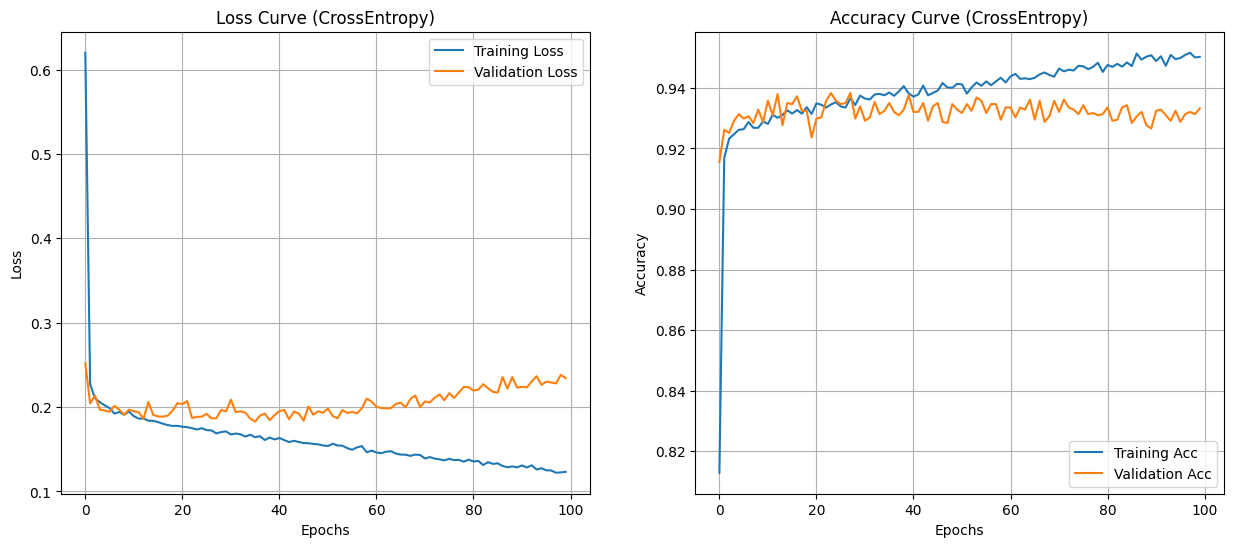

In [ ]:
# --- 5
fig, axes=plt.subplots(1,2, figsize=(15 ,6))
axes[0].plot(history['train_loss'])
axes[0].plot(history['valid_loss'])
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve (CrossEntropy)')
axes[0].grid('True')
axes[0].legend(['Training Loss', 'Validation Loss'])


axes[1].plot(history['train_acc'])
axes[1].plot(history['valid_acc'])
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve (CrossEntropy)')
axes[1].grid('True')
axes[1].legend(['Training Acc', 'Validation Acc'], loc='lower right')

plt.show()

# Early-stopping

In the above, we start doing over-fitting (the loss still decreases for the training data but starts increasing for the validation data). We should stop before this. This is named **early-stopping**. Write a test in the training loop which stop the training when the validation-loss starts increasing.

Epoch: 0	 Training Loss: 0.6413837432379585 | Validation Acc : 0.9100257158279419
Epoch: 5	 Training Loss: 0.19953038895052422 | Validation Acc : 0.9272860884666443
Epoch: 10	 Training Loss: 0.18940166831235514 | Validation Acc : 0.9302240014076233


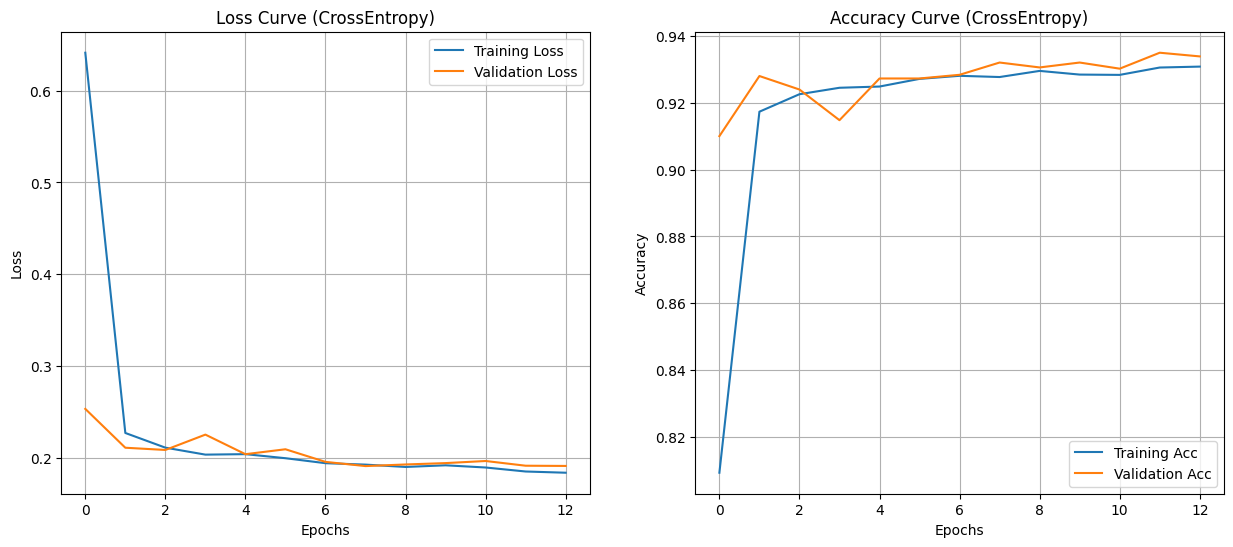

In [ ]:
# --- 6
model = MLP(X_train.shape[1], num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100
history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': []}
min_loss = float("inf")
max_not_improvement = 5 #epochs
not_improved = 0
'''Meaning that if there are 5 consecutive epochs with no improvement, we stop.s'''
# --- 4
for epoch in range(epochs):
    model.train()
    losses_train = []; accs_train = []
    for batch in train_loader:
      optimizer.zero_grad()
      X_i, y_i = batch
      X_i = X_i.to(device)
      y_i = y_i.to(device)

      y_pred=model(X_i)
      loss = criterion(y_pred, y_i)
      losses_train.append(loss.item()*X_i.shape[0])
      preds = torch.argmax(y_pred, axis=1)
      acc_train=torch.sum(y_i==preds, dtype=int)/len(y_i)
      accs_train.append(acc_train*y_i.shape[0])
      loss.backward()

      optimizer.step()

    loss_train = np.sum(losses_train)/len(X_train)
    acc_train = np.sum(accs_train)/len(X_train)

    model.eval()
    losses_valid=[]; accs_valid=[]
    for batch in valid_loader:
      X_i, y_i = batch
      X_i = X_i.to(device)
      y_i = y_i.to(device)

      y_pred=model(X_i)
      loss = criterion(y_pred, y_i)
      losses_valid.append(loss.item()*X_i.shape[0])
      preds = torch.argmax(y_pred, axis=1)
      acc_valid=torch.sum(y_i==preds, dtype=int)/len(y_i)
      accs_valid.append(acc_valid*y_i.shape[0])

    loss_valid = np.sum(losses_valid)/len(X_valid)
    acc_valid = np.sum(accs_valid)/len(X_valid)
    if loss_valid<min_loss:
      min_loss= loss_valid
      not_improved = 0
    else:
      not_improved +=1

    history['train_loss'].append(loss_train)
    history['valid_loss'].append(loss_valid)
    history['train_acc'].append(acc_train)
    history['valid_acc'].append(acc_valid)

    if not_improved ==max_not_improvement:
      break

for epoch in range(len(history['train_loss'])):
  if epoch%5==0:
    print(f"Epoch: {epoch}\t Training Loss: {history['train_loss'][epoch]} | Validation Acc : {history['valid_acc'][epoch]}")

fig, axes=plt.subplots(1,2, figsize=(15 ,6))
axes[0].plot(history['train_loss'])
axes[0].plot(history['valid_loss'])
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve (CrossEntropy)')
axes[0].grid('True')
axes[0].legend(['Training Loss', 'Validation Loss'])


axes[1].plot(history['train_acc'])
axes[1].plot(history['valid_acc'])
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve (CrossEntropy)')
axes[1].grid('True')
axes[1].legend(['Training Acc', 'Validation Acc'], loc='lower right')

plt.show()

**Summary of errors found:**

- ``valid_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)`` : it should be ``valid_dataset`` before.
- ``model = MLP(X_train.shape[0], num_classes).to(device)`` it should use ``X_train.shape[0]`` before which is an error.
- The use of the ``MSE`` Loss + ``Softmax``. We should use instead the ``CrossEntropyLoss``

# Correction (to be done during peer-grading)

During the peer-grading phase, you will note the lab over 10.

- 6 parts are to be filled-in (# --- 1/2/3/4/5/6). You will assign 1 point for each part (the code should be correct and you should be able to run it).
- 2 errors have been introduced in the text and/or provided-code. You will assign 1 point for each error found
- If the whole code run and provides the loss/epoch and accuracy/epoch curves given above (which involves writing the code and correcting the errors), you will give an extra 2 points.